In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_diabetes
df = load_diabetes(as_frame=True).frame



In [ ]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# checking corelations of fetures with the target

# Calculate correlations with the target
correlations = df.corr()['target'].sort_values(ascending=False)

# Filter features with correlation > 0.4
high_corr_features = correlations[(correlations) > 0.4]
print(high_corr_features)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
Name: target, dtype: float64


In [ ]:
# drop the unneccessary columns
x=df.drop(columns=["target","age","sex","bp","s2","s1","s3" ,"s6"],axis=1)
y=df.target

In [ ]:
# x = df.drop('target','age','sex','bp','s2','s1','s3' ,'s6'axis=1)
# y = df.target

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()

In [ ]:
linreg.fit(x_train,y_train)

LinearRegression()

In [ ]:
## prediction
y_pred=linreg.predict(x_test)
y_pred

array([166.32428914, 163.57500469, 191.20822514, 249.27707075,
       137.45639261, 123.35738569, 292.49052854, 224.09300338,
        99.53893093, 146.9747242 , 113.22564782, 131.99099837,
        55.10021967, 188.03322205, 100.48589932, 129.84182173,
       242.07171744, 234.96937   , 152.6501507 , 207.00793844,
       213.39600558, 108.0484439 ,  80.19335674, 187.7190264 ,
       166.61189307, 144.95179468, 181.35913945, 135.58709327,
        62.40622914, 129.92636995, 195.05595642,  90.54219289,
       171.3520322 , 164.74568985, 189.37746369, 227.33145465,
       132.65938962, 134.89335787, 144.15506437,  76.74426079,
        67.44664595, 107.22800151, 137.09969908, 141.55048751,
       163.92481649,  88.27330333,  85.5528532 , 100.92668588,
        45.98939492, 168.51645903, 161.48907499,  75.5186115 ,
       121.14721236, 104.31108989, 165.43892513, 164.01773926,
       102.08061227, 205.39447088, 131.36455509,  97.31837334,
       195.51536028, 198.19723176, 165.01693335, 101.24

MSE is : 2705.4840276750547
MAE is : 41.74819030319159
RMSE is :  52.01426753954202
r2_score is : 0.5107349369399403


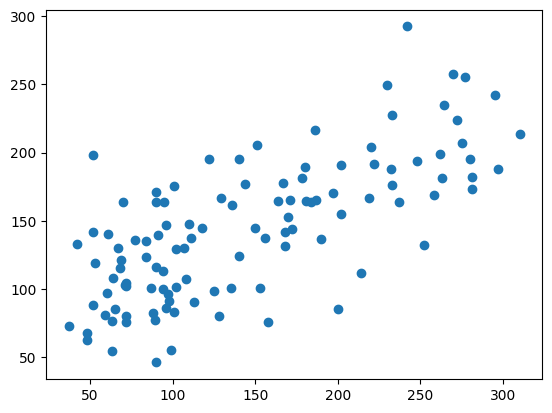

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

<Axes: xlabel='bmi', ylabel='target'>

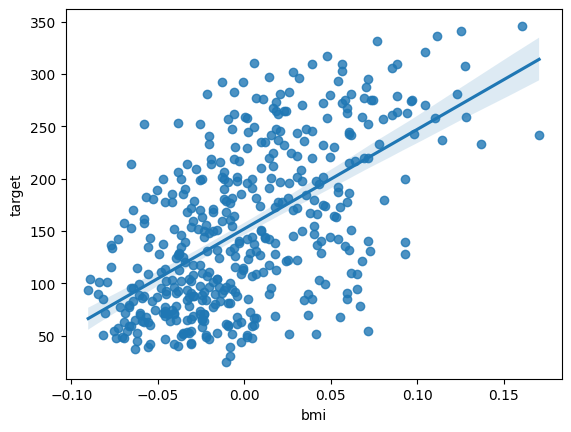

In [ ]:
import seaborn as sns
sns.regplot(x='bmi', y='target', data=df)

<Axes: xlabel='s5', ylabel='target'>

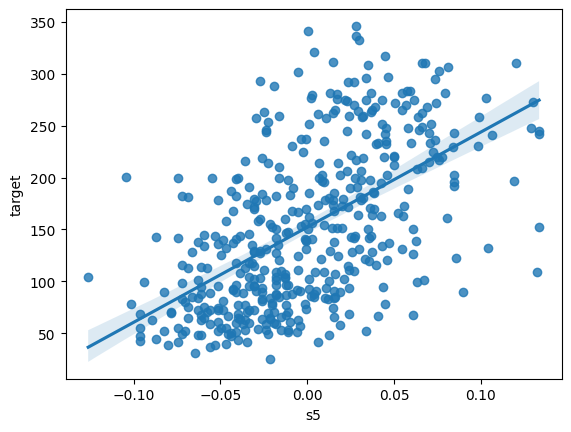

In [ ]:
import seaborn as sns
sns.regplot(x='s5', y='target', data=df)

# Ridge Regression


In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(x_train,y_train)
y_pred=ridge.predict(x_test)

MSE is : 2705.750387294023
MAE is : 41.75663290860828
RMSE is :  52.0168279241826
r2_score is : 0.510686767941551


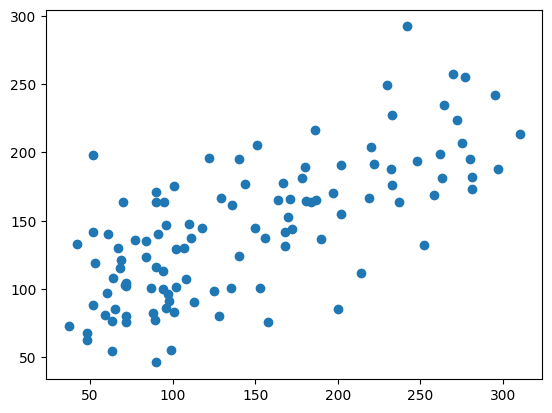

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

### Ridge HyperTuning

In [ ]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train,y_train)
y_pred=ridgecv.predict(x_test)


MSE is : 2709.2757091308686
MAE is : 41.831133982670664
RMSE is :  52.05070325299043
r2_score is : 0.5100492417934874


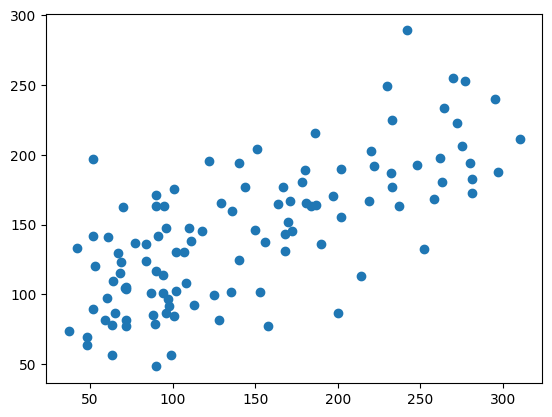

In [ ]:
## Performance Metrics Of RIdge Hypertuning
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

In [ ]:
ridgecv.alpha_

np.float64(10.0)

## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(x_train,y_train)
y_pred=lasso.predict(x_test)

MSE is : 2713.2247546972662
MAE is : 41.89050637114107
RMSE is :  52.08862404304097
r2_score is : 0.5093350886111709


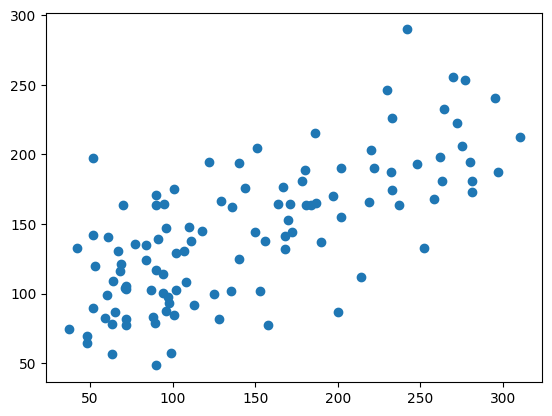

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

### hyperparameter tuning of lasso

In [ ]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_train,y_train)
y_pred=lassocv.predict(x_test)



In [ ]:
lassocv.alpha_

np.float64(0.045974287031255494)

MSE is : 2705.7614353849053
MAE is : 41.75302911833943
RMSE is :  52.01693412135038
r2_score is : 0.5106847699830241


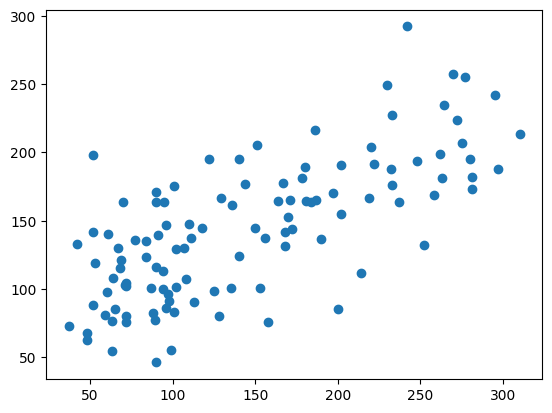

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

## Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(x_train,y_train)
y_pred=elastic.predict(x_test)

MSE is : 2916.172061503371
MAE is : 44.42250539736794
RMSE is :  54.001593138567415
r2_score is : 0.47263369771525543


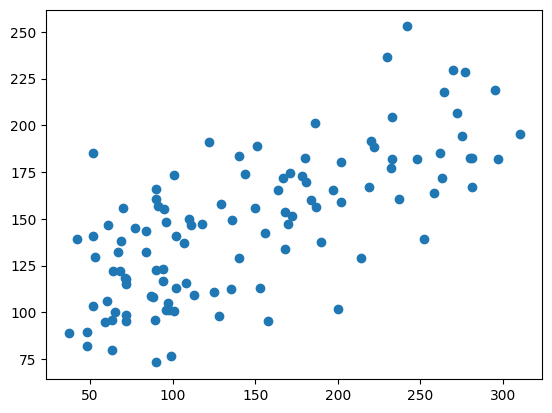

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)

## Hypertuning of ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(x_train,y_train)
y_pred=elasticnetcv.predict(x_test)



MSE is : 2712.5722473262776
MAE is : 41.885271387388094
RMSE is :  52.08236023190844
r2_score is : 0.509453089329988


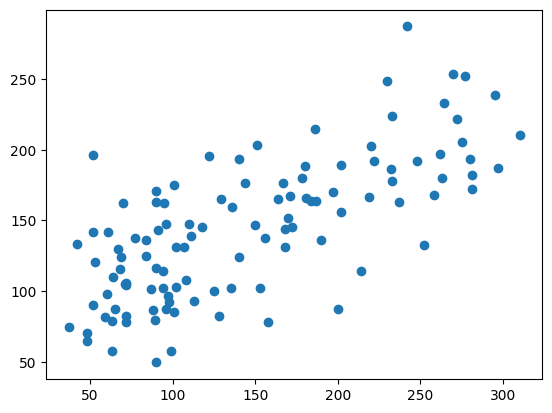

In [ ]:
## Performance Metrics after HYpertuning the Elastic net
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("MSE is :",mse)
print("MAE is :",mae)
print("RMSE is : ",rmse)
print("r2_score is :",score)

plt.scatter(y_test,y_pred)